In [2]:
import pandas as pd
import folium
import matplotlib.pyplot as plt

from folium.plugins import HeatMap
from folium.features import DivIcon

In [9]:
# 1) Cargar puestos de votacion como string
path = '../data/ESTADÍSTICAS_DE_LAS_PERSONAS_DESMOVILIZADAS_QUE_HAN_INGRESADO_AL_PROCESO_DE_REINTEGRACIÓN_20260504.csv'
df = pd.read_csv(path, encoding='utf-8', dtype=str)

In [4]:
print(df.size)
print(df.columns)
print(df.head())

2211924
Index(['Tipo de Desmovilización', 'Ex Grupo', 'Año desmovilización',
       'Ingresó/No ingresó', 'Año de Independización/Ingreso', 'Grupo Etario',
       'Sexo', 'Situación Final frente al proceso',
       'Departamento de residencia descripción',
       'Municipio de residencia descripción', 'Departamento de residencia',
       'Municipio de residencia', 'BeneficioTRV', 'BeneficioFA',
       'BeneficioFPT', 'BeneficioPDT', 'Nivel Educativo',
       'Máximo Nivel FpT Reportado', 'Línea de FpT para el Máx. Nivel',
       'OcupacionEconomica', 'Desembolso BIE', 'Tipo de BIE Accedido',
       'DesagregadoDesembolsoBIE', 'Estado ISUN', 'Posee Servicio Social?',
       'Estado de la vinculación ASS', 'Tipo de ASS Vinculada',
       'Posee Censo de Familia?', 'Posee Cónyuge o Compañero(a)?',
       'N° de Hijos', 'Total Integrantes grupo familiar',
       'Posee Censo de Habitabilidad?', 'Tipo de Vivienda',
       'Régimen de tenencia Vivienda', 'Posee Serv. Públicos Básicos',
     

In [10]:
df.rename(columns={'Año desmovilización': 'año'}, inplace=True)
df.rename(columns={'Departamento de residencia descripción': 'departamento'}, inplace=True)

# limpiar la columna año voliendolo str y removiendo . 
df['año'] = df['año'].astype(str).str.replace('.', '')

In [11]:
# Contar por departamento ordenar por cantidad
df.groupby('departamento').size().sort_values(ascending=False)

departamento
Antioquia                                                   12234
Bogotá D.C.                                                  5485
Meta                                                         3394
Córdoba                                                      3241
Cesar                                                        3029
Valle del Cauca                                              2995
<No Registra>                                                2601
Santander                                                    2453
Magdalena                                                    1997
Cundinamarca                                                 1847
Tolima                                                       1408
Atlántico                                                    1393
Norte de Santander                                           1387
Bolívar                                                      1352
Huila                                                        13

In [12]:
# contar cuantos registros hay en el dataset
print(f"Total de registros: {df.shape[0]}")

Total de registros: 56716


In [13]:
# Contar por registro ordenar por year orden por anio el nombre de la nueva columna es casos
df.groupby('año').size().sort_index(ascending=False)

año
2026       18
2025      280
2024      134
2023      103
2022      153
2021      195
2020      203
2019      244
2018      404
2017      811
2016      668
2015      767
2014      962
2013     1059
2012      906
2011     1214
2010     2009
2009     2549
2008     2858
2007     2729
2006    19607
2005    12020
2004     4374
2003     2438
2002        9
2001        2
dtype: int64

<Axes: xlabel='año'>

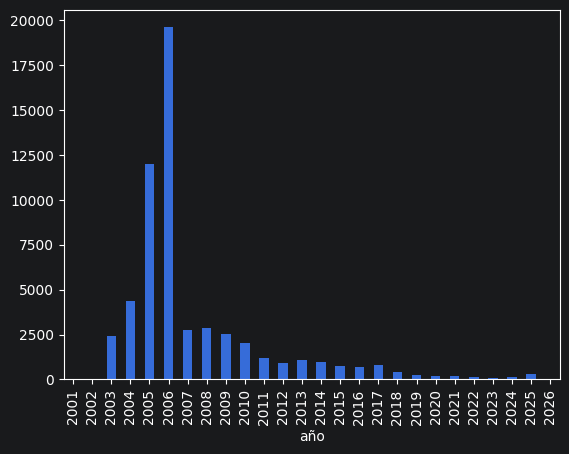

In [14]:
# crear una gradfica de barras con el conteo por anio donde la x sea el anio y la y el conteo de casos
# ordenar de la x por anio
conteo_anio = df.groupby('año').size().sort_index()
conteo_anio.plot(kind='bar', x='año', y='count')


In [16]:
# Contar por departamento ordenar por year orden por anio
df.groupby('Ex Grupo').size().sort_index(ascending=False)

Ex Grupo
SIN DATO MINDEFENSA       93
SIN DATO                  74
GAO Residual             195
GAO Pelusos                2
GAO Clan del Golfo        20
GAO Caparros               4
FARC                   17753
ERP                      170
ERG                      140
EPL                      135
ELN                     4776
AUC                    33354
dtype: int64

In [18]:
# Contar por dano generado
df.groupby('Ingresó/No ingresó').size().sort_index(ascending=False)

Ingresó/No ingresó
Sí    54068
No     2648
dtype: int64

In [17]:
# Contar por grupo étnico
df.groupby('Ingresó/No ingresó').size().sort_index(ascending=False)

Ingresó/No ingresó
Sí    54068
No     2648
dtype: int64

In [ ]:

# Contar por grupo étnico
df.groupby('rangoedad').size().sort_index(ascending=False)

In [2]:

# Contar por grupo étnico
df.groupby('estado').size().sort_index(ascending=False)

NameError: name 'situacion_minas' is not defined

In [3]:
# Cuantos muertos civiles hay
df[(df['genero'] == 'Muerto') & (df['condicion'] == 'Civil')].shape[0]

NameError: name 'situacion_minas' is not defined

In [31]:
# Cuantos ninos muertos
df[(df['genero'] == 'Muerto') & (df['rangoedad'] == 'Menor de 18 años')].shape[0]

259